# ch206 — Tangent Lines

**Part VII: Calculus**

---

## 1. The Tangent Line as Local Linear Approximation

The tangent line at a point (x₀, f(x₀)) is the best linear approximation to f near x₀.

**Equation of the tangent line:**
$$L(x) = f(x_0) + f'(x_0)(x - x_0)$$

This is the **linearization** of f at x₀. For x near x₀, f(x) ≈ L(x).

The derivative f'(x₀) *(introduced in ch205 — Derivative Concept)* is the slope of this line. The tangent is not just a geometric curiosity — it is the local linear model of f, and it is the foundation of Taylor series *(ch219)* and Newton's method.

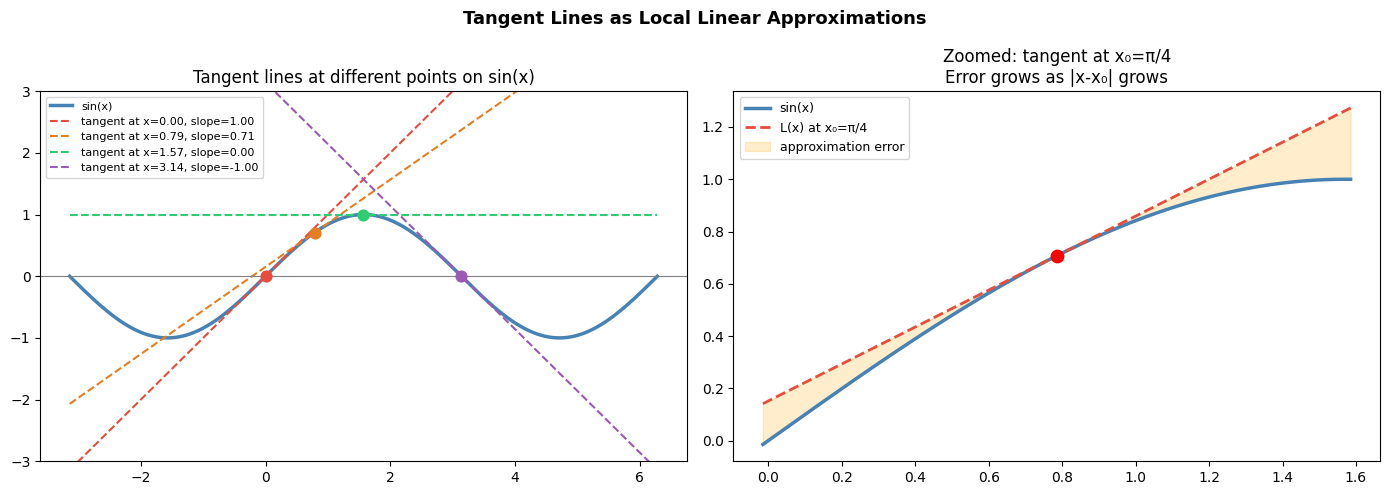

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def tangent_line(f, fp, x0, x_range):
    """Return y values of the tangent line to f at x0, evaluated over x_range."""
    return f(x0) + fp(x0) * (x_range - x0)

# f(x) = sin(x), f'(x) = cos(x)
f  = np.sin
fp = np.cos

x = np.linspace(-np.pi, 2*np.pi, 500)
points = [0, np.pi/4, np.pi/2, np.pi]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: tangent lines at several points
axes[0].plot(x, f(x), color='steelblue', linewidth=2.5, label='sin(x)')
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#9b59b6']
for x0, color in zip(points, colors):
    tan_y = tangent_line(f, fp, x0, x)
    axes[0].plot(x, tan_y, color=color, linewidth=1.5, linestyle='--',
                 label=f'tangent at x={x0:.2f}, slope={fp(x0):.2f}')
    axes[0].scatter([x0], [f(x0)], color=color, zorder=6, s=60)
axes[0].set_ylim(-3, 3)
axes[0].set_title('Tangent lines at different points on sin(x)')
axes[0].legend(fontsize=8)
axes[0].axhline(0, color='gray', linewidth=0.8)

# Right: zoom to show quality of linear approximation
x0 = np.pi/4
x_zoom = np.linspace(x0 - 0.8, x0 + 0.8, 300)
f_zoom = f(x_zoom)
L_zoom = tangent_line(f, fp, x0, x_zoom)
error  = np.abs(f_zoom - L_zoom)

ax2 = axes[1]
ax2.plot(x_zoom, f_zoom, color='steelblue', linewidth=2.5, label='sin(x)')
ax2.plot(x_zoom, L_zoom, color='#e74c3c', linewidth=2, linestyle='--',
         label=f'L(x) at x₀=π/4')
ax2.fill_between(x_zoom, f_zoom, L_zoom, alpha=0.2, color='orange', label='approximation error')
ax2.scatter([x0], [f(x0)], color='red', zorder=6, s=80)
ax2.set_title(f'Zoomed: tangent at x₀=π/4\nError grows as |x-x₀| grows')
ax2.legend(fontsize=9)

plt.suptitle('Tangent Lines as Local Linear Approximations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Quantifying the Approximation Error

The tangent line approximation L(x) = f(x₀) + f'(x₀)(x-x₀) has error:

$$f(x) - L(x) \approx \frac{f''(x_0)}{2}(x - x_0)^2$$

The error is **quadratic** in the distance from x₀. This is why the approximation is excellent near x₀ and degrades further away. *(The second derivative f''(x₀) is the subject of ch217.)*

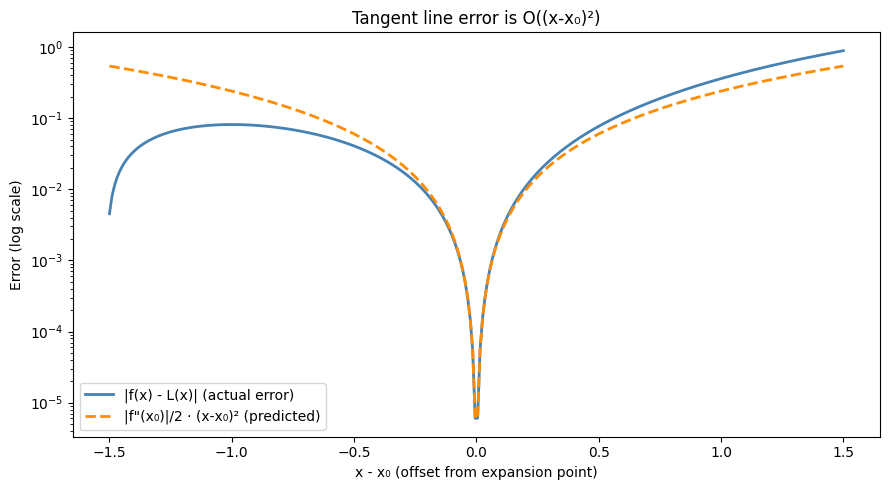

At offset 0.1: actual error = 2.30e-03  predicted = 2.18e-03
At offset 1.0: actual error = 3.58e-01  predicted = 2.39e-01


In [2]:
# f(x) = sin(x), f''(x) = -sin(x)
f   = np.sin
fp  = np.cos
fpp = lambda x: -np.sin(x)  # second derivative

x0 = 0.5
offsets = np.linspace(-1.5, 1.5, 300)
x_vals = x0 + offsets

true_vals    = f(x_vals)
linear_approx = f(x0) + fp(x0) * offsets
actual_error = np.abs(true_vals - linear_approx)
predicted_error = 0.5 * np.abs(fpp(x0)) * offsets**2

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(offsets, actual_error + 1e-16, color='steelblue', linewidth=2, label='|f(x) - L(x)| (actual error)')
ax.semilogy(offsets, predicted_error + 1e-16, color='darkorange', linewidth=2, linestyle='--',
            label='|f"(x₀)|/2 · (x-x₀)² (predicted)')
ax.set_xlabel('x - x₀ (offset from expansion point)')
ax.set_ylabel('Error (log scale)')
ax.set_title('Tangent line error is O((x-x₀)²)')
ax.legend()
plt.tight_layout()
plt.show()

print('At offset 0.1: actual error =', f'{actual_error[abs(offsets-0.1).argmin()]:.2e}',
      ' predicted =', f'{predicted_error[abs(offsets-0.1).argmin()]:.2e}')
print('At offset 1.0: actual error =', f'{actual_error[abs(offsets-1.0).argmin()]:.2e}',
      ' predicted =', f'{predicted_error[abs(offsets-1.0).argmin()]:.2e}')

## 3. Newton's Method: Using Tangent Lines to Find Roots

In [3]:
def newtons_method(f, fp, x0, n_steps=10, tol=1e-12):
    """
    Find root of f using Newton's method.
    Update: x_{n+1} = x_n - f(x_n) / f'(x_n)
    
    This is gradient descent on |f(x)|^2, using the tangent line intersection
    as the next guess.
    """
    x = x0
    history = [x]
    for i in range(n_steps):
        dx = f(x) / fp(x)
        x = x - dx
        history.append(x)
        if abs(dx) < tol:
            break
    return x, history

# Find √2: solve x^2 - 2 = 0
f  = lambda x: x**2 - 2
fp = lambda x: 2*x
root, history = newtons_method(f, fp, x0=1.0)

print('Newton\'s method to find √2')
print(f'{"Step":>5}  {"x_n":>18}  {"f(x_n)":>16}  {"error":>14}')
print('-' * 60)
for i, x in enumerate(history):
    err = abs(x - np.sqrt(2))
    print(f'{i:>5}  {x:>18.14f}  {f(x):>16.2e}  {err:>14.2e}')

print(f'\nTrue √2 = {np.sqrt(2):.14f}')
print('Newton\'s method converges quadratically — error roughly squares each step.')

Newton's method to find √2
 Step                 x_n            f(x_n)           error
------------------------------------------------------------
    0    1.00000000000000         -1.00e+00        4.14e-01
    1    1.50000000000000          2.50e-01        8.58e-02
    2    1.41666666666667          6.94e-03        2.45e-03
    3    1.41421568627451          6.01e-06        2.12e-06
    4    1.41421356237469          4.51e-12        1.59e-12
    5    1.41421356237310          4.44e-16        0.00e+00
    6    1.41421356237309         -4.44e-16        2.22e-16

True √2 = 1.41421356237310
Newton's method converges quadratically — error roughly squares each step.


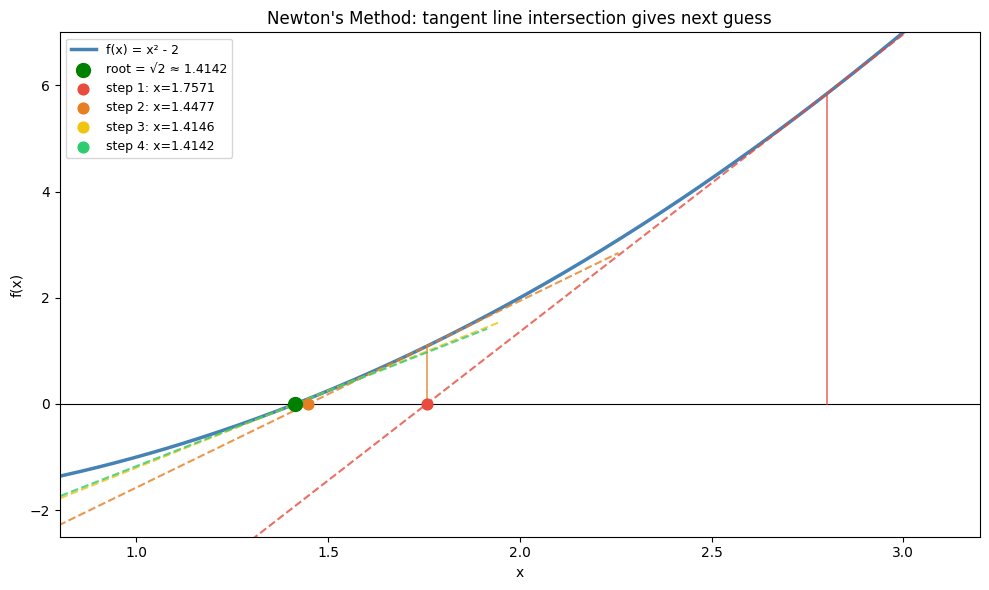

In [4]:
# Visualize Newton's method steps
f  = lambda x: x**2 - 2
fp = lambda x: 2*x

x_plot = np.linspace(0.5, 3, 400)
root, history = newtons_method(f, fp, x0=2.8, n_steps=5)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_plot, f(x_plot), color='steelblue', linewidth=2.5, label='f(x) = x² - 2')
ax.axhline(0, color='black', linewidth=0.8)
ax.scatter([np.sqrt(2)], [0], color='green', zorder=8, s=100, label=f'root = √2 ≈ {np.sqrt(2):.4f}')

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
for i in range(min(4, len(history)-1)):
    x_n = history[i]
    x_next = history[i+1]
    tan_x = np.linspace(x_n - 1.5, x_n + 0.5, 100)
    tan_y = f(x_n) + fp(x_n) * (tan_x - x_n)
    ax.plot(tan_x, tan_y, color=colors[i], linestyle='--', linewidth=1.5, alpha=0.8)
    # Vertical line from x_n to tangent
    ax.plot([x_n, x_n], [0, f(x_n)], color=colors[i], linewidth=1.2, alpha=0.8)
    # Mark x_next (tangent crosses x-axis)
    ax.scatter([x_next], [0], color=colors[i], zorder=7, s=60,
               label=f'step {i+1}: x={x_next:.4f}')

ax.set_xlim(0.8, 3.2)
ax.set_ylim(-2.5, 7)
ax.set_title("Newton's Method: tangent line intersection gives next guess")
ax.legend(fontsize=9)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
plt.tight_layout()
plt.show()

## 4. Summary

- Tangent line at (x₀, f(x₀)): L(x) = f(x₀) + f'(x₀)(x - x₀)
- This is the local linear model of f — best first-order approximation
- Error is quadratic: O((x-x₀)²), involving f''(x₀)
- Newton's method uses tangent line intersections to find roots — converges quadratically
- The tangent line is the first term of the Taylor series (ch219)

---

## 5. Forward References

The tangent line is the degree-1 Taylor polynomial. Adding higher-order terms gives the full Taylor series in ch219 — Taylor Series. Newton's method — tangent-line-based root finding — connects to second-order optimization methods (Newton-Raphson, L-BFGS) that will reappear when discussing advanced optimizers in ch291 — Optimization Methods.